# **Hospital Readmission Rates - Data Visualisation and EDA**

## Objectives

* Import dataset from "Clean Data" file
* Determine conclusions from visualisations of data
* Perform Statistical Analyses of data where possible
* Challenge Hypotheses via conclusions

## Inputs

* Dataset from the "Clean Data" CSV file, imported from the "Clean Data" folder

## Outputs

* Statistical Analysis of dataset
* Visualisations created from Clean dataset
* Conclusions based off of data visualisation and EDA (Exploratory Data Analysis)



---

# Hypotheses

The hypotheses for the dataset are as follows: 

1) Age: 
    * H<sub>0</sub>: Age has no impact on diabetes patient readmittance rates to hospital
2) Race:
    * H<sub>0</sub>: Race has no impact on diabetes patient readmittance rates to hospital
3) 

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\hospital_readmission_rates_analysis\\hospital_readmission_rates_analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\hospital_readmission_rates_analysis\\hospital_readmission_rates_analysis'

---

# Import required packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import scipy
from scipy.stats import ttest_ind

---

# Import Clean Dataset

The clean dataset must be imported as a new dataframe for use in visualisations.

In [5]:
clean_hospital_data_df = pd.read_csv("data_files/CleanData/clean_hospital_data.csv")
clean_hospital_data_df

,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),1,41,0,1,0,0,0,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),3,59,0,18,0,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),2,44,1,16,0,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,51,0,8,0,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99467,AfricanAmerican,Male,[70-80),3,51,0,16,0,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,>30
99468,AfricanAmerican,Female,[80-90),5,33,3,18,0,0,1,...,No,Steady,No,No,No,No,No,No,Yes,NO
99469,Caucasian,Male,[70-80),1,53,0,9,1,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,NO
99470,Caucasian,Female,[80-90),10,45,2,21,0,0,1,...,No,Up,No,No,No,No,No,Ch,Yes,NO


---

In [6]:
clean_hospital_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99472 entries, 0 to 99471
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      99472 non-null  object
 1   gender                    99472 non-null  object
 2   age                       99472 non-null  object
 3   time_in_hospital          99472 non-null  int64 
 4   num_lab_procedures        99472 non-null  int64 
 5   num_procedures            99472 non-null  int64 
 6   num_medications           99472 non-null  int64 
 7   number_outpatient         99472 non-null  int64 
 8   number_emergency          99472 non-null  int64 
 9   number_inpatient          99472 non-null  int64 
 10  diag_1                    99472 non-null  object
 11  diag_2                    99137 non-null  object
 12  diag_3                    98124 non-null  object
 13  max_glu_serum             99472 non-null  object
 14  A1Cresult             

# Visualisations

The visualisations for the data will be split between numerical and categoric data for cleaner EDA.

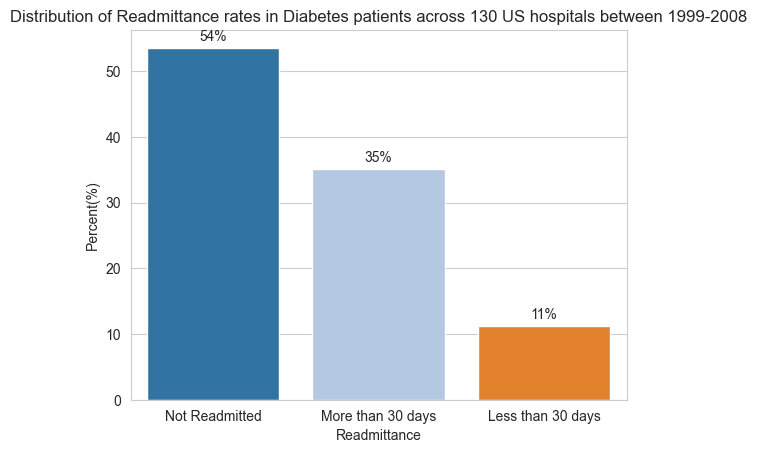

In [21]:
readmittance_percentage_plot = sns.countplot (data = clean_hospital_data_df, x="readmitted", order= clean_hospital_data_df["readmitted"].value_counts().index, hue= "readmitted", palette ="tab20", stat = "percent" )

for container in readmittance_percentage_plot.containers:
    labels = [f'{v.get_height():.0f}%' for v in container]
    readmittance_percentage_plot.bar_label(container, labels=labels, padding= 3)


plt.title("Distribution of Readmittance rates in Diabetes patients across 130 US hospitals between 1999-2008")
plt.xlabel("Readmittance")
plt.xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
plt.ylabel("Percent(%)")
plt.show()


An initial analysis shows that, in this dataset, only 54% of the patients were not readmitted to hospital. Of the remaining 46%, 11% were readmitted in less than 30 days and 35% were readmitted in more than 30 days since discharge. Further EDA will reveal which patients were more likely to be readmitted

## _Numerical Data_

The numerical data held in this dataset are the following fields:

* Time spent in hospital  - Number of days between admission and discharge
* Number of Lab procedures -  Procedures during the encounter
* Number of non-lab procedures - Procedures  during the encounter
* Number of medications - Medications administered during the encounter
* Number of Outpatient visits - Logged for the year preceding the encounter
* Number of Emergency visits - Logged for the year preceding the encounter
* Number of Inpatient visits - Logged for the year preceding the encounter



Initiall, a short statistical summary of each field will be run.

In [8]:
clean_hospital_data_df[["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications","number_outpatient","number_emergency","number_inpatient"]].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient
count,99472.000000,99472.000000,99472.000000,99472.000000,99472.000000,99472.000000,99472.000000
mean,4.398524,43.074433,1.340679,16.026832,0.373392,0.201333,0.643055
std,2.987179,19.695127,1.703786,8.120211,1.276910,0.940045,1.271399
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000


We will do a correlation heatmap to see if there is any correlation across all numeric columns and readmittance rates in patients.

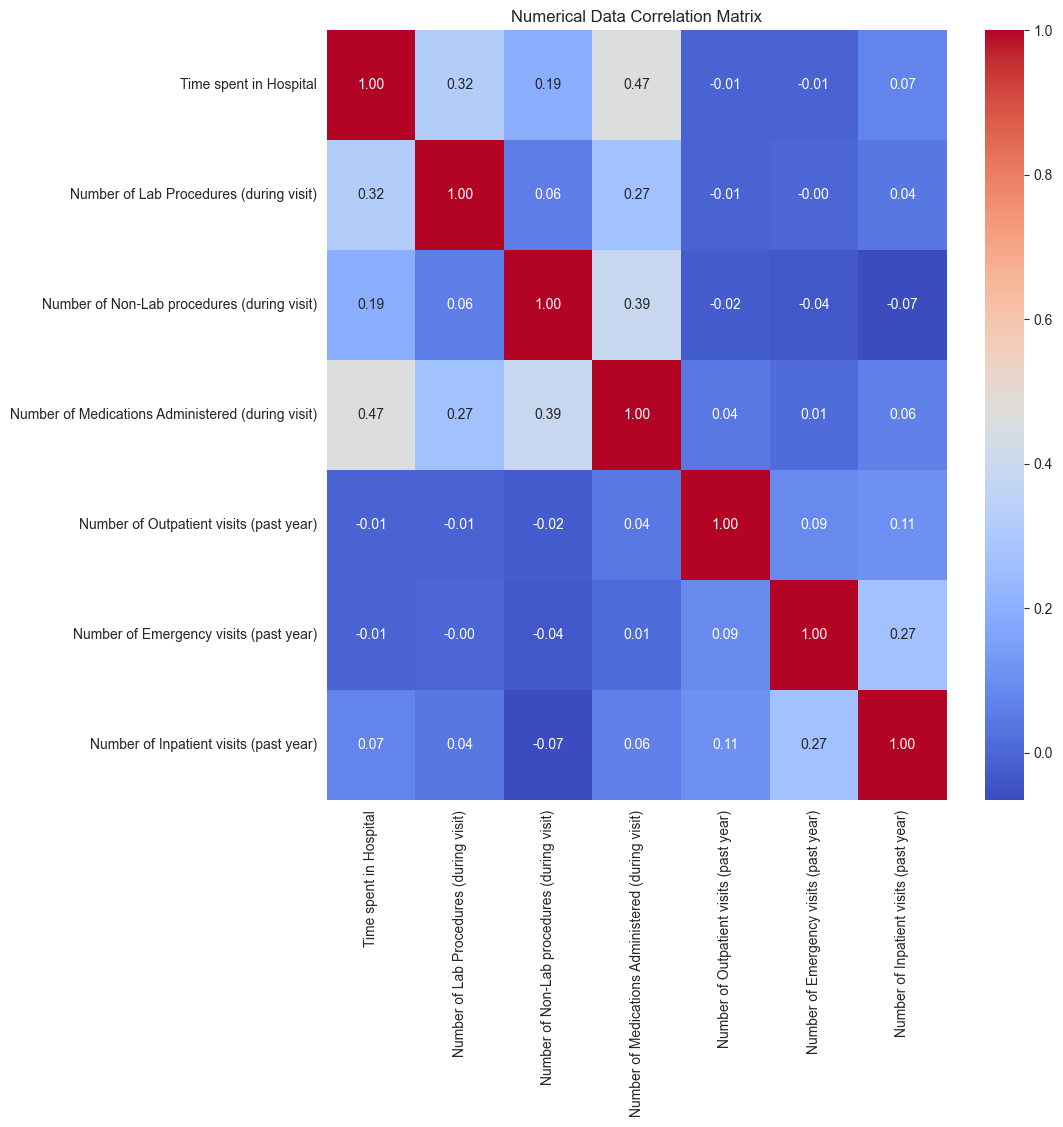

In [16]:
plt.figure(figsize=(10,10))
correlation_matrix_numeric = clean_hospital_data_df[["time_in_hospital", "num_lab_procedures", "num_procedures", 
                                                     "num_medications","number_outpatient","number_emergency","number_inpatient"]].corr()
correlation_matrix_numeric_labels = ["Time spent in Hospital", "Number of Lab Procedures (during visit)", 
                                     "Number of Non-Lab procedures (during visit)", "Number of Medications Administered (during visit)",
                                     "Number of Outpatient visits (past year)","Number of Emergency visits (past year)","Number of Inpatient visits (past year)"]

sns.heatmap(
    correlation_matrix_numeric,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=correlation_matrix_numeric_labels,
    yticklabels= correlation_matrix_numeric_labels
)
plt.title("Numerical Data Correlation Matrix")
plt.show()

---

# Conclusions